# Carga de conjunto de datos

In [23]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from models import Autoencoder
from utils import get_device, crear_conjuntos_proporcionales_estandarizados, mostrar_resumen

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
print(df.shape)

# Quitamos atributos no necesarios
df = df.drop(columns=["id", "Unnamed: 32"])

# Reemplazamos los valores en diagnosis por 0 y 1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Dividimos nuestro conjuntos de datos y lo estandarizamos respecto a la división de entrenamiento, original: B = 357, M = 212
conjuntos = crear_conjuntos_proporcionales_estandarizados(df, "diagnosis", 0.2)

device = get_device()

# Desempaquetamos los conjuntos A, B y C
x_train_0, x_test_0, y_train_0, y_test_0 = conjuntos[0]  # 0% de anómalos
x_train_1, x_test_1, y_train_1, y_test_1 = conjuntos[1]  # 10% de anómalos
x_train_2, x_test_2, y_train_2, y_test_2 = conjuntos[2]  # 25% de anómalos
print(x_train_0.shape)

# Es el mismo conjunto de prueba para todos
X = x_test_0
Y = y_test_0

mostrar_resumen(conjuntos)

(569, 33)
Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

(285, 30)
   Proporción  Positivos  Negativos  Total  % Positivos  % Negativos
0        0.00          0        285    285         0.00       100.00
1        0.10         28        257    285         9.82        90.18
2        0.25         71        214    285        24.91        75.09


In [24]:
modelo_A = Autoencoder.load(path="../models/autoencoder_2025-12-05T20.59_lr=0.001_set=A.pth", device=device)
modelo_B = Autoencoder.load(path="../models/autoencoder_2025-12-05T21.02_lr=0.001_set=B.pth", device=device)
modelo_C = Autoencoder.load(path="../models/autoencoder_2025-12-05T21.05_lr=0.001_set=C.pth", device=device)

modelo_A.summary()


Modelo cargado correctamente de '../models/autoencoder_2025-12-05T20.59_lr=0.001_set=A.pth'

Modelo cargado correctamente de '../models/autoencoder_2025-12-05T21.02_lr=0.001_set=B.pth'

Modelo cargado correctamente de '../models/autoencoder_2025-12-05T21.05_lr=0.001_set=C.pth'
<Autoencoder: In 30 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 30 Out>


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


# Histograma de errores de reconstrucción

Si se entrena un Autoencoder con un conjunto de datos $X$ (de entrenamiento) y luego se evalúa con un conjunto $T$ (de prueba) que sigue la misma distribución, se espera que:

$$
\lVert t'_1 - t_1 \rVert < \epsilon,
\qquad
t'_1 = \text{Decodificador}(\text{Codificador}(t_1)),
\qquad
t_1 \in T.
$$

El valor de $\epsilon$ (epsilon) se calcula de la siguiente manera:

$$
\epsilon =
\begin{cases}
\max(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 0, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 1, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) + 2\,\operatorname{std}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 2.
\end{cases}
$$


In [25]:
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-03T20.28_lr=0.01_set=0.pth", device=device) # buen modelo
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-03T23.50_lr=0.001_set=0.pth", device=device) # bueno también
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-04T00.06_lr=0.001_set=0.pth", device=device) # buen modelo

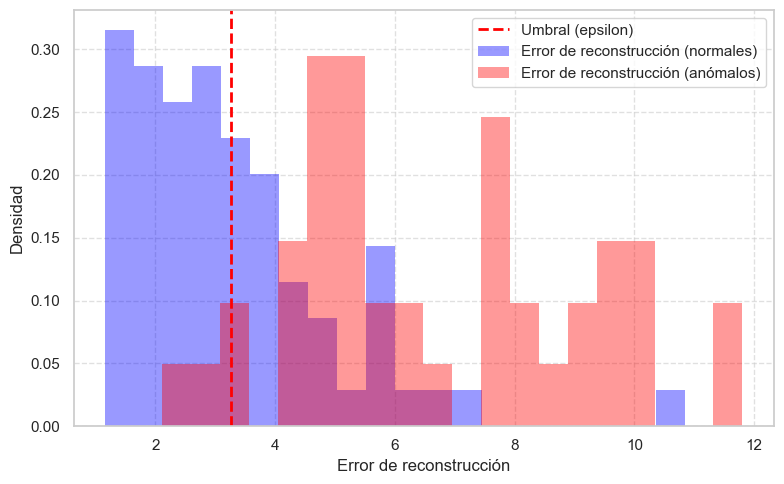

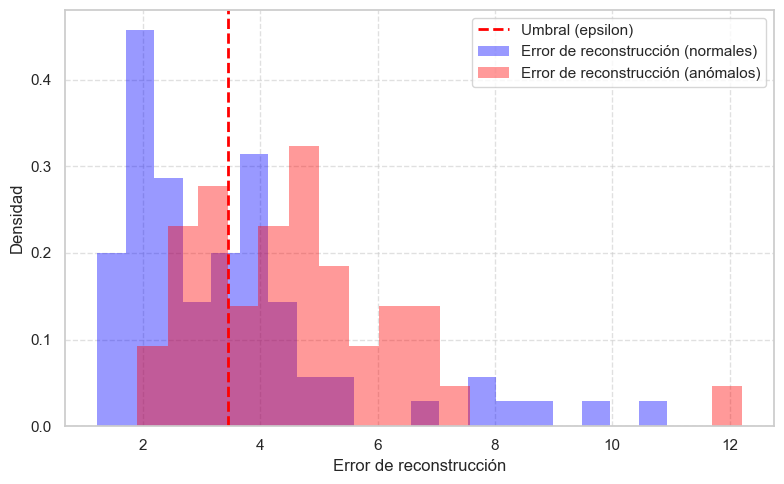

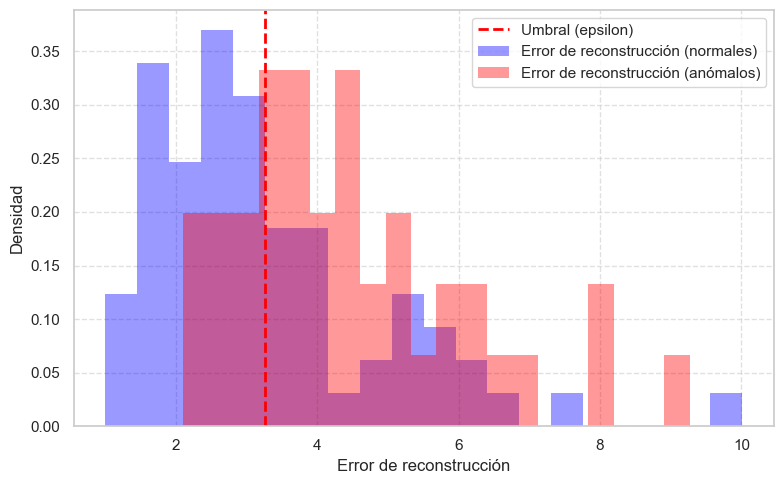

In [26]:
from utils import evaluar_reconstruccion, obtener_epsilon, graficar_histograma_errores_reconstruccion

_, _, dif_norm_A = evaluar_reconstruccion(modelo_A, X[Y==0], device)
_, _, dif_anom_A = evaluar_reconstruccion(modelo_A, X[Y==1], device)

_, _, dif_norm_B = evaluar_reconstruccion(modelo_B, X[Y==0], device)
_, _, dif_anom_B = evaluar_reconstruccion(modelo_B, X[Y==1], device)

_, _, dif_norm_C = evaluar_reconstruccion(modelo_C, X[Y==0], device)
_, _, dif_anom_C = evaluar_reconstruccion(modelo_C, X[Y==1], device)

epsilon_A = obtener_epsilon(dif_norm_A, tipo_epsilon=1)
epsilon_B = obtener_epsilon(dif_norm_B, tipo_epsilon=1)
epsilon_C = obtener_epsilon(dif_norm_C, tipo_epsilon=1)

graficar_histograma_errores_reconstruccion(dif_norm_A, dif_anom_A, epsilon=epsilon_A, kde=False, bins=20)
graficar_histograma_errores_reconstruccion(dif_norm_B, dif_anom_B, epsilon=epsilon_B, kde=False, bins=20)
graficar_histograma_errores_reconstruccion(dif_norm_C, dif_anom_C, epsilon=epsilon_C, kde=False, bins=20)

# Matriz de confusión y métricas

Luego las métricas se obtienen como:

$$
\begin{array}{rcl rcl}
\text{Accuracy} & = &
\dfrac{\text{TP} + \text{TN}}
      {\text{TP} + \text{FP} + \text{TN} + \text{FN}}
&
\text{Precision} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FP}}
\\[14pt]

\text{Recall} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FN}}
&
\text{Specificity} & = &
\dfrac{\text{TN}}
      {\text{TN} + \text{FP}}
\\[14pt]

\text{Balanced Accuracy} & = &
\dfrac{\dfrac{\text{TP}}{\text{TP}+\text{FN}} + \dfrac{\text{TN}}{\text{TN}+\text{FP}}}{2}
&
\text{F1\_Score} & = &
\dfrac{2\,\text{TP}}
      {2\,\text{TP} + \text{FP} + \text{FN}}
\end{array}
$$

{'accuracy': 0.7105, 'precision': 0.5634, 'recall': 0.9524, 'specificity': 0.5694, 'balanced_accuracy': 0.7609, 'f1_score': 0.708}


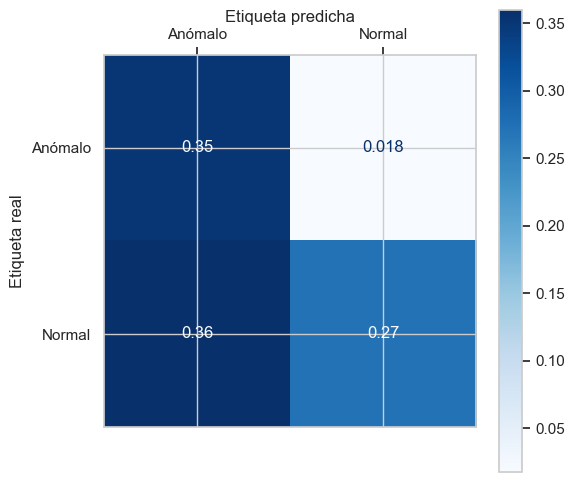

{'accuracy': 0.6228, 'precision': 0.4915, 'recall': 0.6905, 'specificity': 0.5833, 'balanced_accuracy': 0.6369, 'f1_score': 0.5743}


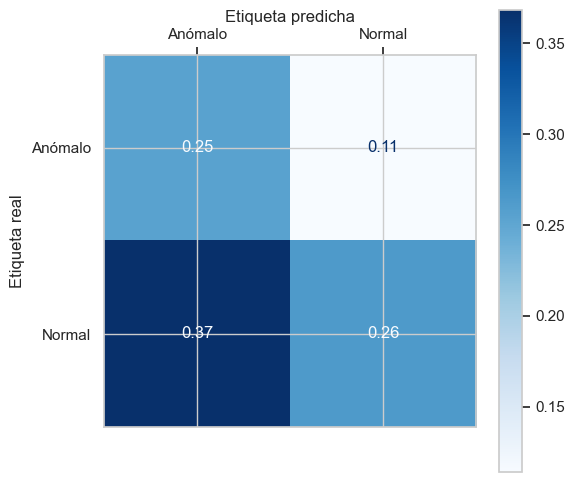

{'accuracy': 0.6667, 'precision': 0.5345, 'recall': 0.7381, 'specificity': 0.625, 'balanced_accuracy': 0.6815, 'f1_score': 0.62}


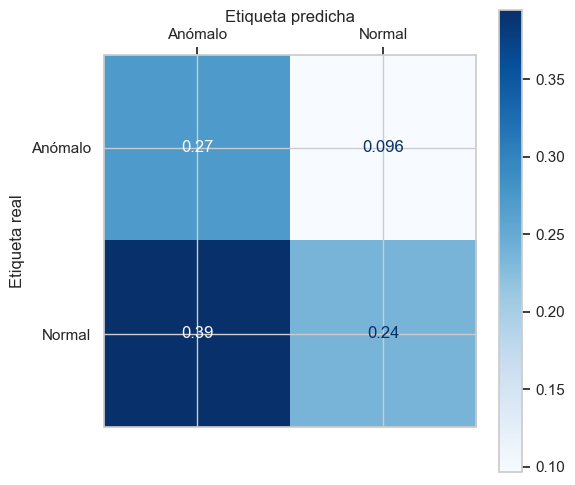

In [27]:
from utils import obtener_matriz_confusion, obtener_metricas, graficar_matriz_confusion

TP, FN, TN, FP = obtener_matriz_confusion(dif_norm_A, dif_anom_A, epsilon_A)
metricas = obtener_metricas(TP, FN, TN, FP)
print(metricas)
graficar_matriz_confusion(TP, FN, TN, FP)

TP, FN, TN, FP = obtener_matriz_confusion(dif_norm_B, dif_anom_B, epsilon_B)
metricas = obtener_metricas(TP, FN, TN, FP)
print(metricas)
graficar_matriz_confusion(TP, FN, TN, FP)

TP, FN, TN, FP = obtener_matriz_confusion(dif_norm_C, dif_anom_C, epsilon_C)
metricas = obtener_metricas(TP, FN, TN, FP)
print(metricas)
graficar_matriz_confusion(TP, FN, TN, FP)

# Espacio latente

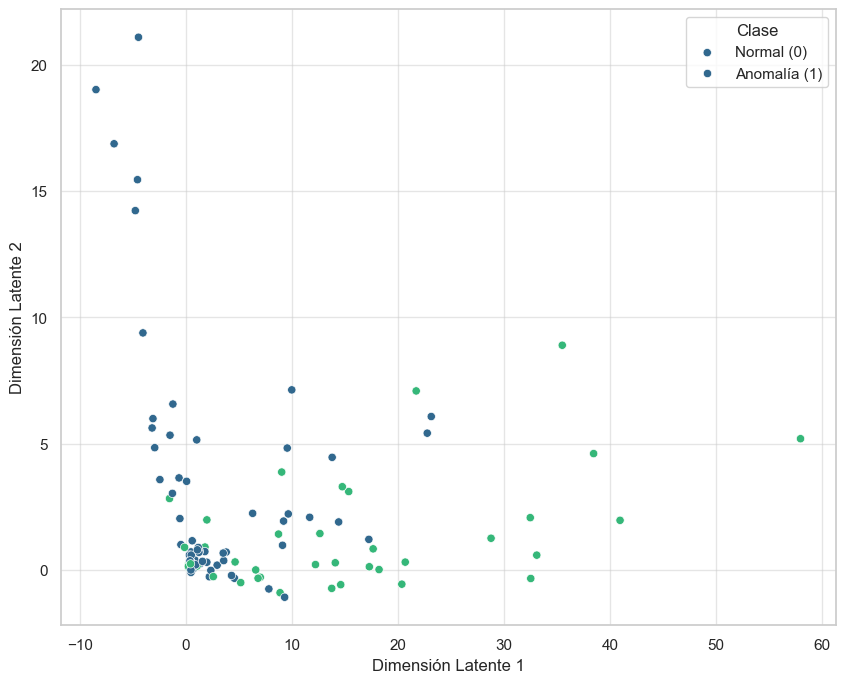

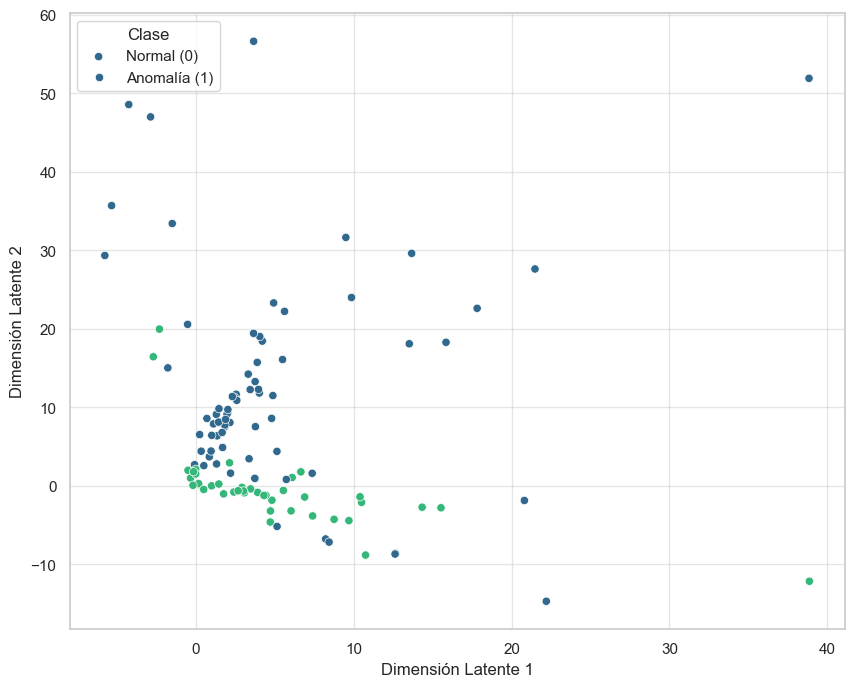

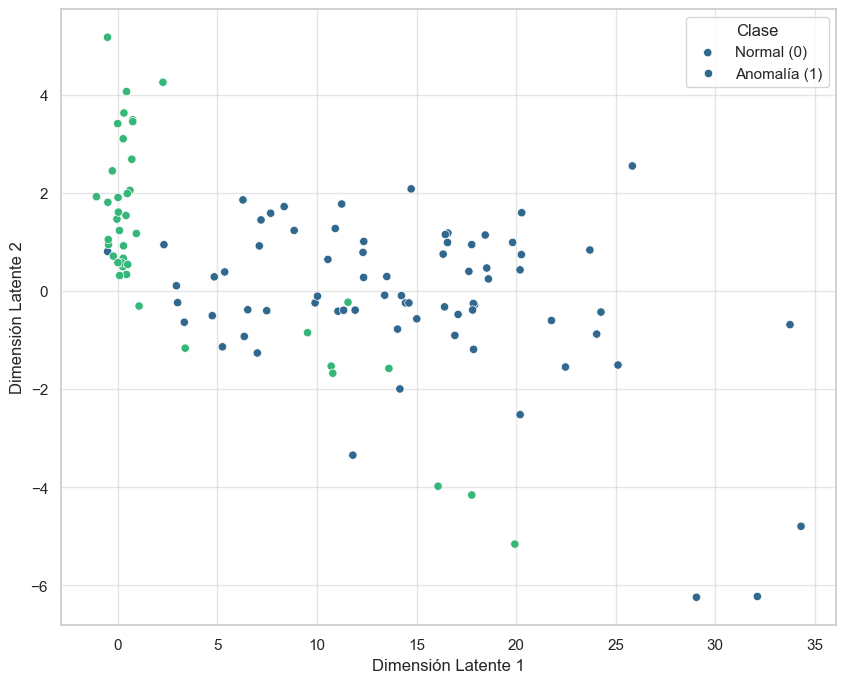

In [28]:
from utils import graficar_espacio_latente

z_A = modelo_A.encode(X, device)

graficar_espacio_latente(z_A, Y, ["Normal (0)", "Anomalía (1)"])

z_B = modelo_B.encode(X, device)

graficar_espacio_latente(z_B, Y, ["Normal (0)", "Anomalía (1)"])

z_C = modelo_C.encode(X, device)

graficar_espacio_latente(z_C, Y, ["Normal (0)", "Anomalía (1)"])

# Curva ROC y AUC

Tamaño de conjunto de test: 114


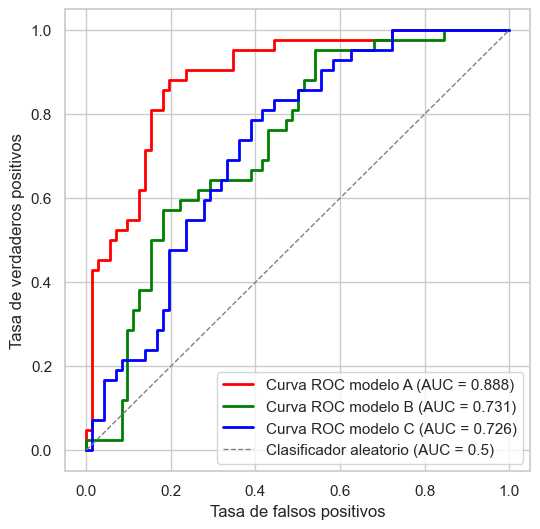

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print(f"Tamaño de conjunto de test: {len(X)}")

_, _, errores_A = evaluar_reconstruccion(modelo_A, X, device)
_, _, errores_B = evaluar_reconstruccion(modelo_B, X, device)
_, _, errores_C = evaluar_reconstruccion(modelo_C, X, device)

fpr_A, tpr_A, thresholds = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, thresholds = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, thresholds = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6,6))

plt.plot(fpr_A, tpr_A, color='red', lw=2, label=f'Curva ROC modelo A (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color='green', lw=2, label=f'Curva ROC modelo B (AUC = {roc_auc_B:.3f})')
plt.plot(fpr_C, tpr_C, color='blue', lw=2, label=f'Curva ROC modelo C (AUC = {roc_auc_C:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05 ,1.05])
plt.show()

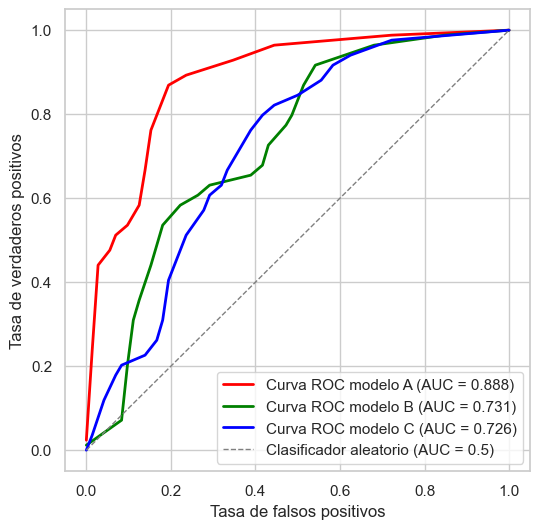

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid")

_, _, errores_A = evaluar_reconstruccion(modelo_A, X, device)
_, _, errores_B = evaluar_reconstruccion(modelo_B, X, device)
_, _, errores_C = evaluar_reconstruccion(modelo_C, X, device)

fpr_A, tpr_A, thresholds = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, thresholds = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, thresholds = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6,6))

sns.lineplot(x=fpr_A, y=tpr_A, color='red', lw=2, label=f'Curva ROC modelo A (AUC = {roc_auc_A:.3f})', errorbar=None)
sns.lineplot(x=fpr_B, y=tpr_B, color='green', lw=2, label=f'Curva ROC modelo B (AUC = {roc_auc_B:.3f})', errorbar=None)
sns.lineplot(x=fpr_C, y=tpr_C, color='blue', lw=2, label=f'Curva ROC modelo C (AUC = {roc_auc_C:.3f})', errorbar=None)

sns.lineplot(x=[0, 1], y=[0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)', errorbar=None)

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05 ,1.05])
plt.show()
